# MIMIC-IV — Ranking Stability Study (complete pipeline)

> **Research question:** Does the performance ranking of machine learning algorithms
> for ICU in-hospital mortality prediction remain the same when models are evaluated by
> forward-in-time temporal validation instead of random data splitting?

Ten algorithms, two experimental designs, one notebook.

| Family | Models |
|---|---|
| Linear | Logistic Regression (elastic net) |
| Bagged trees | Random Forest |
| Boosted trees | XGBoost, LightGBM, CatBoost |
| Neural (tabular) | MLP, FT-Transformer |
| Sequence | LSTM, GRU-D, Temporal Fusion Transformer |
| Reference (not ranked) | Modified SOFA, SAPS-II-lite |

| | Design A | Design B |
|---|---|---|
| Train | 70% random, all eras | E1&ndash;E3 (2008&ndash;2016) |
| Validation | 15% random | E4 (2017&ndash;2019) |
| Test | 15% random | E5 (2020&ndash;2022) |

---

### Before running

1. **Enable GPU:** Runtime &rarr; Change runtime type &rarr; T4. The four neural models need it.
2. **Prerequisites:** `mimic_extraction.sql` and `mimic_sequences.sql` must have run in
   BigQuery, and `mimic_icu_mortality_24h.parquet` must exist on Drive.

### Resumability

Everything checkpoints to Drive. Optuna studies persist to SQLite; completed models are
written to CSV as they finish and skipped on re-run. **If Colab disconnects, just re-run
from the top** &mdash; it picks up where it stopped rather than starting over.

Expect 6&ndash;14 hours total at 30 trials. Run it in stages.

## 1. Configuration

In [1]:
!pip install -q optuna xgboost lightgbm catboost

import os, json, time, warnings, itertools, shutil
import numpy as np, pandas as pd
import torch, torch.nn as nn
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# ---- PATHS (Kaggle) --------------------------------------------------------
# Walk the whole input tree rather than hard-coding paths: Kaggle's mount
# depth varies, and you have the DB in two datasets.
FOUND = {}
for root, _, files in os.walk('/kaggle/input'):
    for f in files:
        p = os.path.join(root, f)
        # keep the LARGEST match - for optuna_studies.db that is the copy
        # with the most completed trials
        if f not in FOUND or os.path.getsize(p) > os.path.getsize(FOUND[f]):
            FOUND[f] = p

PARQUET = FOUND.get('mimic_icu_mortality_24h.parquet')
SEQFILE = FOUND.get('sequences.parquet')
SRC_DB  = FOUND.get('optuna_studies.db')

OUT_DIR = '/kaggle/working/results'
os.makedirs(OUT_DIR, exist_ok=True)

# Kaggle input is read-only but Optuna must WRITE to the SQLite file,
# so copy it into the working dir first.
dst_db = f'{OUT_DIR}/optuna_studies.db'
if SRC_DB and not os.path.exists(dst_db):
    shutil.copy(SRC_DB, dst_db)

STORAGE   = f"sqlite:///{dst_db}"
RESULTS_F = f"{OUT_DIR}/all_model_results.csv"
PREDS_F   = f"{OUT_DIR}/all_predictions.npz"

print("Parquet  :", PARQUET)
print("Sequences:", SEQFILE)
print("Optuna DB:", SRC_DB)
if os.path.exists(dst_db):
    kb = os.path.getsize(dst_db) / 1e3
    print(f"          -> {kb:.0f} kB",
          "  <-- UPDATED db" if kb > 400 else "  <-- WARNING: OLD db, expect re-tuning")

assert PARQUET and SEQFILE, "Data files not found - check Add Input"

# ---- BUDGET: identical for every algorithm ---------------------------------
N_TRIALS = 30
N_SEEDS  = 5
SEED     = 42

# ---- Neural training -------------------------------------------------------
MAX_EPOCHS, PATIENCE = 60, 8
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print("\nDevice:", DEVICE)
if DEVICE == 'cpu':
    print("*** No GPU. Settings > Accelerator > GPU T4 x2")

Parquet  : /kaggle/input/datasets/dianakopiyo/dataset/mimic_icu_mortality_24h.parquet
Sequences: /kaggle/input/datasets/dianakopiyo/dataset/sequences.parquet
Optuna DB: /kaggle/input/datasets/dianakopiyo/dataset1/optuna_studies.db
          -> 504 kB   <-- UPDATED db

Device: cuda


## 2. Data and splits

In [2]:
df = pd.read_parquet(PARQUET)

# Guard rails
assert 'mortality' in df and 'era' in df
assert 'los' not in df.columns,         "Leakage column 'los' present"
assert 'n_diagnoses' not in df.columns, "'n_diagnoses' present (post-window leakage)"

# Pandas nullable extension dtypes (Int64/Float64/boolean) break CatBoost and
# torch.tensor(). Convert to plain numpy dtypes before anything downstream.
for col in df.columns:
    if str(df[col].dtype) in ('Int64', 'Float64', 'boolean'):
        df[col] = df[col].astype('float64')
df[TARGET_TMP := 'mortality'] = df['mortality'].astype('int64')

n_str = sum(1 for x in df.columns if not pd.api.types.is_numeric_dtype(df[x]))
assert n_str <= 8, f"{n_str} non-numeric columns"

TARGET, DESIGN, KEY = 'mortality', 'era', 'stay_id'
FEATURES    = [x for x in df.columns if x not in [TARGET, DESIGN, KEY]]
CATEGORICAL = [x for x in FEATURES if not pd.api.types.is_numeric_dtype(df[x])]
NUMERIC     = [x for x in FEATURES if x not in CATEGORICAL]
POS_W       = float((df[TARGET]==0).sum() / (df[TARGET]==1).sum())

print(f"{len(df):,} stays | {len(FEATURES)} features "
      f"({len(NUMERIC)} numeric, {len(CATEGORICAL)} categorical)")
print(f"Prevalence {100*df[TARGET].mean():.2f}%  positive weight {POS_W:.2f}")

32,315 stays | 260 features (253 numeric, 7 categorical)
Prevalence 11.17%  positive weight 7.95


In [3]:
from sklearn.model_selection import train_test_split

def make_splits(design, seed=SEED):
    """Each stay is a distinct patient (first stays only), so stay-level and
    patient-level partitions coincide - no group-aware splitting needed."""
    if design == 'A':
        idx = np.arange(len(df))
        tr, tmp = train_test_split(idx, test_size=.30,
                                   stratify=df[TARGET], random_state=seed)
        va, te  = train_test_split(tmp, test_size=.50,
                                   stratify=df[TARGET].iloc[tmp], random_state=seed)
        return tr, va, te
    e = df[DESIGN].values
    return (np.where(np.isin(e, ['E1','E2','E3']))[0],
            np.where(e == 'E4')[0],
            np.where(e == 'E5')[0])

SPLITS = {d: make_splits(d) for d in ['A','B']}
for d in ['A','B']:
    tr,va,te = SPLITS[d]
    print(f"Design {d}:  train {len(tr):>6,} ({int(df[TARGET].iloc[tr].sum()):>4,} deaths)"
          f" | val {len(va):>6,} ({int(df[TARGET].iloc[va].sum()):>4,})"
          f" | test {len(te):>6,} ({int(df[TARGET].iloc[te].sum()):>4,})")

Design A:  train 22,620 (2,528 deaths) | val  4,847 ( 541) | test  4,848 ( 542)
Design B:  train 19,044 (2,012 deaths) | val  7,321 ( 792) | test  5,950 ( 807)


### Preprocessing

**The critical rule:** imputation medians, scaling statistics and category levels are
fitted on the **training partition only**, then applied unchanged to validation and test.

In Design B that means medians from 2008&ndash;2016 applied to 2020&ndash;2022 data. That is not a
shortcut &mdash; it is exactly the deployment condition under study. Fitting on the full
dataset would leak the test era into preprocessing and invalidate the comparison.

In [4]:
from sklearn.preprocessing import StandardScaler

class Preprocessor:
    def fit(self, X):
        self.med_ = X[NUMERIC].median()
        self.lev_ = {ccc: sorted(X[ccc].dropna().unique().tolist()) for ccc in CATEGORICAL}
        Xt = self._raw(X)
        self.cols_ = Xt.columns.tolist()
        self.sc_ = StandardScaler().fit(Xt.values)
        return self
    def _raw(self, X):
        o = X[NUMERIC].fillna(self.med_).copy()
        for ccc in CATEGORICAL:
            for lv in self.lev_[ccc]:
                o[f"{ccc}__{lv}"] = (X[ccc] == lv).astype(int)
        return o
    def transform(self, X, scaled=False):
        Xt = self._raw(X).reindex(columns=self.cols_, fill_value=0)
        if scaled:
            return pd.DataFrame(self.sc_.transform(Xt.values),
                                columns=Xt.columns, index=Xt.index)
        return Xt

TAB = {}
for d in ['A','B']:
    tr, va, te = SPLITS[d]
    pre = Preprocessor().fit(df.iloc[tr])
    TAB[d] = {}
    for nm, idx in [('train',tr), ('val',va), ('test',te)]:
        TAB[d][nm] = dict(X        = pre.transform(df.iloc[idx]),
                          X_scaled = pre.transform(df.iloc[idx], scaled=True),
                          y        = df[TARGET].values[idx])

# Design A and B have DIFFERENT widths (332 vs 323): one-hot levels are fitted
# on each design's own training partition, and E1-E3 contains fewer categorical
# levels than a random sample spanning all eras. FT-Transformer must be built
# to match whichever design it is training on.
N_TAB_BY_DESIGN = {d: TAB[d]['train']['X'].shape[1] for d in ['A','B']}
CURRENT_DESIGN = 'A'
print("Tabular widths by design:", N_TAB_BY_DESIGN)

Tabular widths by design: {'A': 332, 'B': 323}


## 3. Sequence tensors

Shapes the hourly table into `(n_stays, 24, n_channels)` plus a mask and a
time-since-last-observation channel &mdash; the three inputs GRU-D requires.

Both representations come from one extraction with identical filters, so any difference
between tabular and sequence models reflects architecture rather than preprocessing.

In [5]:
SEQ_CACHE = SEQFILE

if os.path.exists(SEQ_CACHE):
    seq = pd.read_parquet(SEQ_CACHE)
    print("Loaded cached sequences:", seq.shape)
else:
    auth.authenticate_user()
    from google.cloud import bigquery
    client = bigquery.Client(project=BQ_PROJECT)
    seq = client.query(
        f"SELECT stay_id, hour, feat, val FROM `{BQ_PROJECT}.mimic_study.sequences`"
    ).to_dataframe()
    for col in ['stay_id','hour','val']:
        seq[col] = pd.to_numeric(seq[col], errors='coerce')   # BigQuery dtype trap
    seq.to_parquet(SEQ_CACHE, index=False)
    print("Pulled and cached:", seq.shape)

SEQ_FEATS = sorted(seq.feat.unique())
F, T, N = len(SEQ_FEATS), 24, len(df)
print(f"{F} channels x {T} hours:", SEQ_FEATS)

Loaded cached sequences: (6181909, 4)
22 channels x 24 hours: ['anion_gap', 'bicarbonate', 'bun', 'creatinine', 'dbp', 'gcs_eye', 'gcs_motor', 'gcs_verbal', 'glucose', 'hemoglobin', 'hr', 'lactate', 'map', 'ph', 'platelets', 'potassium', 'rr', 'sbp', 'sodium', 'spo2', 'temp', 'wbc']


In [6]:
# Dense array in the same row order as df, so indices align with the tabular splits.
stay_pos = {s:i for i,s in enumerate(df[KEY].values)}
feat_pos = {f:j for j,f in enumerate(SEQ_FEATS)}

X_seq = np.full((N, T, F), np.nan, dtype=np.float32)
si = seq.stay_id.map(stay_pos).values
ok = ~pd.isna(si)
X_seq[si[ok].astype(int),
      seq.hour.values[ok].astype(int),
      seq.feat.map(feat_pos).values[ok].astype(int)] = seq.val.values[ok]

MASK = (~np.isnan(X_seq)).astype(np.float32)
print(f"X_seq {X_seq.shape}   observed cells {100*MASK.mean():.1f}%")


def build_seq(design):
    tr, va, te = SPLITS[design]
    # Channel statistics from TRAINING stays only.
    mu = np.nan_to_num(np.nanmean(X_seq[tr].reshape(-1,F), axis=0))
    sd = np.nan_to_num(np.nanstd(X_seq[tr].reshape(-1,F), axis=0), nan=1.0)
    sd[sd == 0] = 1.0
    Z = (X_seq - mu) / sd

    # delta = hours since this channel was last observed (GRU-D decay input)
    delta = np.zeros_like(Z, dtype=np.float32)
    for t in range(1, T):
        delta[:,t,:] = np.where(MASK[:,t-1,:]==1, 1.0, delta[:,t-1,:]+1.0)

    # forward-fill for LSTM/TFT, which have no native missingness handling
    Zf = Z.copy()
    for t in range(1, T):
        Zf[:,t,:] = np.where(np.isnan(Zf[:,t,:]), Zf[:,t-1,:], Zf[:,t,:])
    Zf = np.nan_to_num(Zf); Z = np.nan_to_num(Z)

    out = {}
    for nm, idx in [('train',tr), ('val',va), ('test',te)]:
        out[nm] = dict(x_raw=torch.tensor(Z[idx]),
                       x_ff =torch.tensor(Zf[idx]),
                       mask =torch.tensor(MASK[idx]),
                       delta=torch.tensor(delta[idx]/24.0),
                       y    =torch.tensor(df[TARGET].values[idx], dtype=torch.float32))
    return out

SEQ = {d: build_seq(d) for d in ['A','B']}

# Torch tabular tensors for FT-Transformer
TABT = {d: {s: dict(x=torch.tensor(TAB[d][s]['X_scaled'].values, dtype=torch.float32),
                    y=torch.tensor(TAB[d][s]['y'], dtype=torch.float32))
            for s in ['train','val','test']} for d in ['A','B']}

print("Design A train sequence tensor:", SEQ['A']['train']['x_raw'].shape)

X_seq (32315, 24, 22)   observed cells 35.9%
Design A train sequence tensor: torch.Size([22620, 24, 22])


## 4. Evaluation

Primary metric is **AUPRC**, fixed in advance. At ~11% prevalence, AUROC is inflated by
the large true-negative count; AUPRC is not.

In [7]:
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss
from sklearn.linear_model import LogisticRegression

def cal_si(y, p):
    """Calibration slope and intercept. Perfect = slope 1, intercept 0.
    Slope < 1 means over-confidence on new data."""
    p = np.clip(p, 1e-6, 1-1e-6)
    lg = np.log(p/(1-p)).reshape(-1,1)
    try:
        m = LogisticRegression(C=np.inf, solver='lbfgs', max_iter=1000).fit(lg, y)
    except (TypeError, ValueError):
        m = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000).fit(lg, y)
    return float(m.coef_[0][0]), float(m.intercept_[0])

def evaluate(y, p):
    sl, ic = cal_si(y, p)
    return dict(auprc=average_precision_score(y,p), auroc=roc_auc_score(y,p),
                brier=brier_score_loss(y,p), cal_slope=sl, cal_intercept=ic,
                prevalence=float(np.mean(y)))
print("Ready.")

Ready.


## 5. Neural architectures

In [8]:
class FTTransformer(nn.Module):
    """Each feature becomes a token; a CLS token aggregates for classification."""
    def __init__(s, nf, d=64, blocks=3, heads=8, dropout=.1):
        super().__init__()
        s.w = nn.Parameter(torch.randn(nf,d)*.02); s.b = nn.Parameter(torch.zeros(nf,d))
        s.cls = nn.Parameter(torch.randn(1,1,d)*.02)
        L = nn.TransformerEncoderLayer(d, heads, d*2, dropout, batch_first=True, norm_first=True)
        s.enc = nn.TransformerEncoder(L, blocks)
        s.head = nn.Sequential(nn.LayerNorm(d), nn.ReLU(), nn.Linear(d,1))
    def forward(s, x):
        t = x.unsqueeze(-1)*s.w + s.b
        t = torch.cat([s.cls.expand(x.size(0),-1,-1), t], 1)
        return s.head(s.enc(t)[:,0]).squeeze(-1)

class LSTMClf(nn.Module):
    def __init__(s, nf, hidden=64, layers=1, dropout=.2):
        super().__init__()
        s.rnn = nn.LSTM(nf, hidden, layers, batch_first=True,
                        dropout=dropout if layers>1 else 0.)
        s.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden,1))
    def forward(s, x, *a):
        o,_ = s.rnn(x); return s.head(o[:,-1]).squeeze(-1)

class GRUD(nn.Module):
    """Learned exponential decay on the last observed value and the hidden state,
    so measurement gaps are modelled rather than imputed away."""
    def __init__(s, nf, hidden=64, dropout=.2):
        super().__init__()
        s.h = hidden
        s.gx = nn.Linear(nf, nf); s.gh = nn.Linear(nf, hidden)
        s.cell = nn.GRUCell(nf*2, hidden)
        s.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden,1))
    def forward(s, x, mask, delta):
        B,Tn,Fn = x.shape
        h = torch.zeros(B, s.h, device=x.device)
        last = torch.zeros(B, Fn, device=x.device)
        for t in range(Tn):
            xt, mt, dt = x[:,t], mask[:,t], delta[:,t]
            gx = torch.exp(-torch.relu(s.gx(dt)))
            gh = torch.exp(-torch.relu(s.gh(dt)))
            xh = mt*xt + (1-mt)*(gx*last)
            last = torch.where(mt.bool(), xt, last)
            h = s.cell(torch.cat([xh, mt], -1), gh*h)
        return s.head(h).squeeze(-1)

class TFTLite(nn.Module):
    """Variable-selection gating, LSTM encoder, interpretable self-attention over time."""
    def __init__(s, nf, hidden=64, heads=4, dropout=.1):
        super().__init__()
        s.vsn = nn.Sequential(nn.Linear(nf,nf), nn.Sigmoid())
        s.proj = nn.Linear(nf, hidden)
        s.rnn = nn.LSTM(hidden, hidden, batch_first=True)
        s.attn = nn.MultiheadAttention(hidden, heads, dropout=dropout, batch_first=True)
        s.norm = nn.LayerNorm(hidden)
        s.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden,1))
    def forward(s, x, *a):
        x = x*s.vsn(x); z = s.proj(x); z,_ = s.rnn(z)
        a_,_ = s.attn(z,z,z); z = s.norm(z+a_)
        return s.head(z[:,-1]).squeeze(-1)

print("Architectures defined.")

Architectures defined.


In [9]:
from torch.utils.data import TensorDataset, DataLoader

def _pack(tens, split, kind):
    d = tens[split]
    if kind=='tabular': return [d['x']]
    if kind=='ff':      return [d['x_ff']]
    return [d['x_raw'], d['mask'], d['delta']]

@torch.no_grad()
def predict_torch(model, tens, split, kind, batch=512):
    model.eval(); xs = _pack(tens, split, kind); out=[]
    for i in range(0, len(tens[split]['y']), batch):
        out.append(torch.sigmoid(model(*[x[i:i+batch].to(DEVICE) for x in xs])).cpu().numpy())
    return np.concatenate(out)

def train_torch(model, tens, kind, lr=1e-3, batch=256, seed=SEED):
    torch.manual_seed(seed); np.random.seed(seed)
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    lossf = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_W, device=DEVICE))
    dl = DataLoader(TensorDataset(*_pack(tens,'train',kind), tens['train']['y']),
                    batch_size=batch, shuffle=True)
    yva = tens['val']['y'].numpy()
    best, state, bad = -1, None, 0
    for ep in range(MAX_EPOCHS):
        model.train()
        for parts in dl:
            *xs, yb = [p.to(DEVICE) for p in parts]
            opt.zero_grad(); loss = lossf(model(*xs), yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        sc = average_precision_score(yva, predict_torch(model, tens, 'val', kind))
        if sc > best: best, state, bad = sc, {k:v.detach().cpu().clone()
                                              for k,v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= PATIENCE: break
    model.load_state_dict(state)
    return model, best
print("Torch training loop ready.")

Torch training loop ready.


## 6. Model registry — all ten

One dispatcher handles both sklearn-style and torch models, so the tuning and final-fit
loops below are identical for every algorithm.

Class imbalance is handled by **class weighting**, never resampling &mdash; resampling
distorts predicted probabilities and would corrupt the calibration analysis.

In [10]:
from sklearn.linear_model import LogisticRegression as LR
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

MODELS = {
 'LogisticRegression': dict(type='sk', scaled=True, family='Linear',
   space=lambda t: dict(C=t.suggest_float('C',1e-4,1e2,log=True),
                        l1_ratio=t.suggest_float('l1_ratio',0.,1.)),
   build=lambda p,s: LR(penalty='elasticnet', solver='saga', C=p['C'],
                        l1_ratio=p['l1_ratio'], class_weight='balanced',
                        max_iter=2000, random_state=s)),

 'RandomForest': dict(type='sk', scaled=False, family='Bagged trees',
   space=lambda t: dict(n_estimators=t.suggest_int('n_estimators',200,800,step=100),
                        max_depth=t.suggest_int('max_depth',3,20),
                        min_samples_leaf=t.suggest_int('min_samples_leaf',1,50),
                        max_features=t.suggest_float('max_features',.1,1.)),
   build=lambda p,s: RandomForestClassifier(**p, class_weight='balanced',
                                            n_jobs=-1, random_state=s)),

 'XGBoost': dict(type='sk', scaled=False, family='Boosted trees',
   space=lambda t: dict(n_estimators=t.suggest_int('n_estimators',100,800,step=50),
                        max_depth=t.suggest_int('max_depth',2,10),
                        learning_rate=t.suggest_float('learning_rate',.01,.3,log=True),
                        subsample=t.suggest_float('subsample',.5,1.),
                        colsample_bytree=t.suggest_float('colsample_bytree',.3,1.),
                        min_child_weight=t.suggest_int('min_child_weight',1,20),
                        reg_lambda=t.suggest_float('reg_lambda',1e-3,10,log=True),
                        reg_alpha=t.suggest_float('reg_alpha',1e-4,10,log=True)),
   build=lambda p,s: XGBClassifier(**p, scale_pos_weight=POS_W, eval_metric='aucpr',
                                   tree_method='hist', n_jobs=-1, random_state=s,
                                   verbosity=0)),

 'LightGBM': dict(type='sk', scaled=False, family='Boosted trees',
   space=lambda t: dict(n_estimators=t.suggest_int('n_estimators',100,800,step=50),
                        num_leaves=t.suggest_int('num_leaves',8,128),
                        learning_rate=t.suggest_float('learning_rate',.01,.3,log=True),
                        min_child_samples=t.suggest_int('min_child_samples',5,100),
                        subsample=t.suggest_float('subsample',.5,1.),
                        colsample_bytree=t.suggest_float('colsample_bytree',.3,1.),
                        reg_lambda=t.suggest_float('reg_lambda',1e-3,10,log=True)),
   build=lambda p,s: LGBMClassifier(**p, class_weight='balanced', n_jobs=-1,
                                    random_state=s, verbose=-1)),

 'CatBoost': dict(type='sk', scaled=False, family='Boosted trees',
   space=lambda t: dict(iterations=t.suggest_int('iterations',200,800,step=100),
                        depth=t.suggest_int('depth',3,10),
                        learning_rate=t.suggest_float('learning_rate',.01,.3,log=True),
                        l2_leaf_reg=t.suggest_float('l2_leaf_reg',1.,30.,log=True)),
   build=lambda p,s: CatBoostClassifier(**p, auto_class_weights='Balanced',
                                        random_seed=s, verbose=0,
                                        allow_writing_files=False)),

 'MLP': dict(type='sk', scaled=True, family='Neural (tabular)',
   space=lambda t: dict(hidden=t.suggest_categorical('hidden',
                            ['128','256','128,64','256,128']),
                        alpha=t.suggest_float('alpha',1e-5,1e-1,log=True),
                        lr=t.suggest_float('lr',1e-4,1e-2,log=True)),
   build=lambda p,s: MLPClassifier(hidden_layer_sizes=tuple(int(x) for x in p['hidden'].split(',')),
                                   alpha=p['alpha'], learning_rate_init=p['lr'],
                                   max_iter=300, early_stopping=True,
                                   n_iter_no_change=15, random_state=s)),

 'FT-Transformer': dict(type='torch', kind='tabular', family='Neural (tabular)',
   space=lambda t: dict(d=t.suggest_categorical('d',[32,64,128]),
                        blocks=t.suggest_int('blocks',1,4),
                        dropout=t.suggest_float('dropout',0.,.4),
                        lr=t.suggest_float('lr',1e-4,5e-3,log=True)),
   build=lambda p,s: FTTransformer(N_TAB_BY_DESIGN[CURRENT_DESIGN],
                                   p['d'], p['blocks'], 8, p['dropout'])),

 'LSTM': dict(type='torch', kind='ff', family='Sequence',
   space=lambda t: dict(hidden=t.suggest_categorical('hidden',[32,64,128]),
                        layers=t.suggest_int('layers',1,2),
                        dropout=t.suggest_float('dropout',0.,.5),
                        lr=t.suggest_float('lr',1e-4,5e-3,log=True)),
   build=lambda p,s: LSTMClf(F, p['hidden'], p['layers'], p['dropout'])),

 'GRU-D': dict(type='torch', kind='grud', family='Sequence',
   space=lambda t: dict(hidden=t.suggest_categorical('hidden',[32,64,128]),
                        dropout=t.suggest_float('dropout',0.,.5),
                        lr=t.suggest_float('lr',1e-4,5e-3,log=True)),
   build=lambda p,s: GRUD(F, p['hidden'], p['dropout'])),

 'TFT': dict(type='torch', kind='ff', family='Sequence',
   space=lambda t: dict(hidden=t.suggest_categorical('hidden',[32,64,128]),
                        heads=t.suggest_categorical('heads',[2,4]),
                        dropout=t.suggest_float('dropout',0.,.4),
                        lr=t.suggest_float('lr',1e-4,5e-3,log=True)),
   build=lambda p,s: TFTLite(F, p['hidden'], p['heads'], p['dropout'])),
}

def tensors_for(name, design):
    cfg = MODELS[name]
    return TABT[design] if cfg.get('kind')=='tabular' else SEQ[design]

def fit_predict(name, design, params, seed, split='test'):
    """Unified interface: returns predicted probabilities and the best val score."""
    global CURRENT_DESIGN
    CURRENT_DESIGN = design      # so FT-Transformer is built at the right width
    cfg = MODELS[name]
    if cfg['type']=='sk':
        d = TAB[design]
        key = 'X_scaled' if cfg['scaled'] else 'X'
        m = cfg['build'](params, seed).fit(d['train'][key], d['train']['y'])
        val = average_precision_score(d['val']['y'], m.predict_proba(d['val'][key])[:,1])
        return m.predict_proba(d[split][key])[:,1], val
    tens = tensors_for(name, design)
    m, val = train_torch(cfg['build'](params, seed), tens, cfg['kind'],
                         lr=params['lr'], seed=seed)
    p = predict_torch(m, tens, split, cfg['kind'])
    del m
    if DEVICE=='cuda': torch.cuda.empty_cache()
    return p, val

print(f"{len(MODELS)} models registered:", ", ".join(MODELS))

10 models registered: LogisticRegression, RandomForest, XGBoost, LightGBM, CatBoost, MLP, FT-Transformer, LSTM, GRU-D, TFT


## 7. Tuning — all ten, both designs

Optuna TPE with `N_TRIALS` per model per design, identical for every algorithm.
Studies persist to SQLite on Drive; a disconnect costs one trial, not the search.

Tuning uses the **validation** partition only. In Design B that is era E4, so E5 never
influences hyperparameter choice.

In [11]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

BEST = {}
for design in ['A','B']:
    for name in MODELS:
        study = optuna.create_study(study_name=f"{name}__design{design}",
                    storage=STORAGE, direction='maximize', load_if_exists=True,
                    sampler=optuna.samplers.TPESampler(seed=SEED))
        done = len([t for t in study.trials
                    if t.state == optuna.trial.TrialState.COMPLETE])
        todo = max(0, N_TRIALS - done)
        if todo:
            t0 = time.time()
            study.optimize(lambda tr, n=name, d=design:
                           fit_predict(n, d, MODELS[n]['space'](tr), SEED, split='val')[1],
                           n_trials=todo)
            el = f"{(time.time()-t0)/60:.1f} min"
        else:
            el = "cached"
        BEST[(name,design)] = study.best_params
        print(f"{name:20s} {design}  val AUPRC {study.best_value:.4f}  ({el})")

json.dump({f"{k[0]}__{k[1]}": v for k,v in BEST.items()},
          open(f"{OUT_DIR}/best_params.json","w"), indent=2)
print("\nSaved best_params.json")

LogisticRegression   A  val AUPRC 0.5469  (cached)
RandomForest         A  val AUPRC 0.5208  (cached)
XGBoost              A  val AUPRC 0.5938  (cached)
LightGBM             A  val AUPRC 0.5959  (cached)
CatBoost             A  val AUPRC 0.5780  (cached)
MLP                  A  val AUPRC 0.5841  (cached)
FT-Transformer       A  val AUPRC 0.5874  (cached)
LSTM                 A  val AUPRC 0.5159  (cached)
GRU-D                A  val AUPRC 0.5270  (cached)
TFT                  A  val AUPRC 0.5220  (cached)
LogisticRegression   B  val AUPRC 0.5868  (cached)
RandomForest         B  val AUPRC 0.5646  (cached)
XGBoost              B  val AUPRC 0.6161  (cached)
LightGBM             B  val AUPRC 0.6268  (cached)
CatBoost             B  val AUPRC 0.6213  (cached)
MLP                  B  val AUPRC 0.5998  (cached)
FT-Transformer       B  val AUPRC 0.6052  (133.7 min)
LSTM                 B  val AUPRC 0.5657  (3.1 min)
GRU-D                B  val AUPRC 0.5853  (34.0 min)
TFT                  B  v

In [12]:
import shutil
shutil.copy(dst_db, '/kaggle/working/optuna_backup_after_tuning.db')
print("Optuna DB backed up to /kaggle/working/")

Optuna DB backed up to /kaggle/working/


## 8. Final fit — 5 seeds each

Checkpointed: completed model/design pairs are written to CSV as they finish and skipped
on re-run. Safe to interrupt.

In [13]:
# Resume from any previous partial run.
if os.path.exists(RESULTS_F):
    res = pd.read_csv(RESULTS_F)
    done = set(zip(res.model, res.design))
    print(f"Resuming: {len(done)} model/design pairs already complete")
else:
    res, done = pd.DataFrame(), set()

preds = {}
if os.path.exists(PREDS_F):
    z = np.load(PREDS_F)
    for k in z.files:
        if k.endswith('__y'):
            n,d,_ = k.split('__'); preds[(n,d)] = (z[k], z[f"{n}__{d}__p"])

rows = res.to_dict('records') if len(res) else []

for design in ['A','B']:
    yte = df[TARGET].values[SPLITS[design][2]]
    for name, cfg in MODELS.items():
        if (name, design) in done:
            continue
        t0 = time.time()
        sp = [fit_predict(name, design, BEST[(name,design)], SEED+s)[0]
              for s in range(N_SEEDS)]
        pm = np.mean(sp, axis=0)
        preds[(name,design)] = (yte, pm)

        r = evaluate(yte, pm)
        r.update(model=name, design=design, family=cfg['family'],
                 auprc_sd=float(np.std([average_precision_score(yte,p) for p in sp])),
                 minutes=round((time.time()-t0)/60, 1))
        rows.append(r)

        # checkpoint after every model
        pd.DataFrame(rows).to_csv(RESULTS_F, index=False)
        np.savez_compressed(PREDS_F,
            **{f"{n}__{d}__y": preds[(n,d)][0] for n,d in preds},
            **{f"{n}__{d}__p": preds[(n,d)][1] for n,d in preds})

        print(f"{name:20s} {design}  AUPRC {r['auprc']:.4f} (sd {r['auprc_sd']:.4f})  "
              f"AUROC {r['auroc']:.4f}  slope {r['cal_slope']:.2f}  [{r['minutes']} min]")

res = pd.DataFrame(rows)
print(f"\nComplete: {len(res)} model/design results")

LogisticRegression   A  AUPRC 0.5551 (sd 0.0000)  AUROC 0.8851  slope 0.75  [24.3 min]
RandomForest         A  AUPRC 0.5576 (sd 0.0017)  AUROC 0.8903  slope 1.27  [9.7 min]
XGBoost              A  AUPRC 0.6256 (sd 0.0037)  AUROC 0.9094  slope 0.98  [0.7 min]
LightGBM             A  AUPRC 0.6159 (sd 0.0031)  AUROC 0.9068  slope 0.32  [0.7 min]
CatBoost             A  AUPRC 0.6121 (sd 0.0029)  AUROC 0.9070  slope 1.10  [1.3 min]
MLP                  A  AUPRC 0.5909 (sd 0.0393)  AUROC 0.8959  slope 1.07  [0.8 min]
FT-Transformer       A  AUPRC 0.5920 (sd 0.0066)  AUROC 0.8978  slope 0.84  [28.3 min]
LSTM                 A  AUPRC 0.5277 (sd 0.0037)  AUROC 0.8755  slope 0.85  [0.8 min]
GRU-D                A  AUPRC 0.5459 (sd 0.0114)  AUROC 0.8820  slope 0.86  [4.7 min]
TFT                  A  AUPRC 0.5414 (sd 0.0038)  AUROC 0.8805  slope 0.92  [2.5 min]
LogisticRegression   B  AUPRC 0.6064 (sd 0.0000)  AUROC 0.8956  slope 0.84  [5.9 min]
RandomForest         B  AUPRC 0.5768 (sd 0.0009)  AU

## 9. Clinical reference scores

Not competitors in the ranking &mdash; a fixed reference line. If hand-engineered scores
prove more temporally stable than learned models, that is a substantive finding.

**Limitation:** full SOFA needs vasopressor dose and PaO2/FiO2; full SAPS-II needs urine
output and ventilation. All come from the tables excluded for ~43% E5 coverage. These
are **modified** scores and must be described that way.

In [14]:
def gcs_total(d):
    return (d.get('gcs_eye_min', pd.Series(4,index=d.index)).fillna(4)
          + d.get('gcs_verbal_min', pd.Series(5,index=d.index)).fillna(5)
          + d.get('gcs_motor_min', pd.Series(6,index=d.index)).fillna(6))

def modified_sofa(d):
    s = pd.Series(0., index=d.index)
    p = d.get('platelets_min')
    if p is not None: s += np.select([p<20,p<50,p<100,p<150],[4,3,2,1],default=0)
    b = d.get('bilirubin_max')
    if b is not None: s += np.select([b>=12,b>=6,b>=2,b>=1.2],[4,3,2,1],default=0)
    g = gcs_total(d); s += np.select([g<6,g<10,g<13,g<15],[4,3,2,1],default=0)
    cr = d.get('creatinine_max')
    if cr is not None: s += np.select([cr>=5,cr>=3.5,cr>=2,cr>=1.2],[4,3,2,1],default=0)
    return s

def saps_lite(d):
    s = pd.Series(0., index=d.index); a = d['anchor_age']
    s += np.select([a>=80,a>=75,a>=70,a>=60,a>=40],[18,16,15,12,7],default=0)
    for col, cond, pts in [
        ('hr_max',      lambda v:[v>=160,v>=120,v<40,v<70],      [7,4,11,2]),
        ('sbp_min',     lambda v:[v<70,v<100,v>=200],            [13,5,2]),
        ('bun_max',     lambda v:[v>=84,v>=28],                  [10,6]),
        ('wbc_max',     lambda v:[v>=20,v<1],                    [3,12]),
        ('sodium_max',  lambda v:[v>=145,v<125],                 [1,5]),
        ('bicarbonate_min', lambda v:[v<15,v<20],                [6,3]),
        ('bilirubin_max',   lambda v:[v>=6,v>=4],                [9,4])]:
        v = d.get(col)
        if v is not None: s += np.select(cond(v), pts, default=0)
    k = d.get('potassium_max')
    if k is not None: s += np.where((k>=5)|(k<3), 3, 0)
    g = gcs_total(d); s += np.select([g<6,g<9,g<11,g<14],[26,13,7,5],default=0)
    return s

df['score_sofa'] = modified_sofa(df)
df['score_saps'] = saps_lite(df)

srows = []
for design in ['A','B']:
    tr,va,te = SPLITS[design]; y = df[TARGET].values[te]
    for nm, col in [('SOFA (modified)','score_sofa'), ('SAPS-II (lite)','score_saps')]:
        lr = LR(max_iter=1000).fit(df[[col]].iloc[tr], df[TARGET].iloc[tr])
        p = lr.predict_proba(df[[col]].iloc[te])[:,1]
        preds[(nm,design)] = (y,p)
        r = evaluate(y,p); r.update(model=nm, design=design,
                                    family='Clinical reference', auprc_sd=0., minutes=0.)
        srows.append(r)

res_all = pd.concat([res, pd.DataFrame(srows)], ignore_index=True)
res_all.to_csv(f"{OUT_DIR}/all_results_with_scores.csv", index=False)
display(pd.DataFrame(srows)[['model','design','auprc','auroc','cal_slope']].round(4))

,model,design,auprc,auroc,cal_slope
0,SOFA (modified),A,0.2896,0.7200,1.0972
1,SAPS-II (lite),A,0.2941,0.7429,1.0586
2,SOFA (modified),B,0.3278,0.7422,1.1594
3,SAPS-II (lite),B,0.3516,0.7514,1.1206


## 10. PRIMARY ANALYSIS — do the rankings agree?

This is the answer to the research question. Clinical scores are excluded from the
ranking; the question is about machine learning algorithms.

In [15]:
from scipy.stats import kendalltau

ML = res_all[res_all.family != 'Clinical reference']
rA = ML[ML.design=='A'].set_index('model')['auprc'].rank(ascending=False)
rB = ML[ML.design=='B'].set_index('model')['auprc'].rank(ascending=False)

comp = pd.DataFrame({'rank_A':rA, 'rank_B':rB,
    'auprc_A': ML[ML.design=='A'].set_index('model')['auprc'],
    'auprc_B': ML[ML.design=='B'].set_index('model')['auprc'],
    'family':  ML[ML.design=='A'].set_index('model')['family']})
comp['rank_change']     = (comp.rank_A - comp.rank_B).astype(int)
comp['degradation']     = (comp.auprc_A - comp.auprc_B).round(4)
comp['degradation_pct'] = (100*comp.degradation/comp.auprc_A).round(1)
comp = comp.sort_values('rank_A')
display(comp.round(4))

tau, pval = kendalltau(comp.rank_A, comp.rank_B)
moved = int((comp.rank_change.abs() >= 2).sum())

print(f"\n{'='*64}")
print(f"  Kendall tau-b           {tau:.3f}   (p = {pval:.4f})")
print(f"  Models moving >=2 ranks {moved} / {len(comp)}")
print(f"  Mean degradation        {comp.degradation.mean():.4f} AUPRC "
      f"({comp.degradation_pct.mean():.1f}%)")
print(f"  Best under Design A     {comp.index[0]}")
print(f"  Best under Design B     {comp.sort_values('rank_B').index[0]}")
print('='*64)

,rank_A,rank_B,auprc_A,auprc_B,family,rank_change,degradation,degradation_pct
model,,,,,,,,
XGBoost,1.0,2.0,0.6256,0.6268,Boosted trees,-1,-0.0011,-0.2
LightGBM,2.0,1.0,0.6159,0.6372,Boosted trees,1,-0.0213,-3.5
CatBoost,3.0,4.0,0.6121,0.6213,Boosted trees,-1,-0.0092,-1.5
FT-Transformer,4.0,3.0,0.5920,0.6217,Neural (tabular),1,-0.0297,-5.0
MLP,5.0,5.0,0.5909,0.6200,Neural (tabular),0,-0.0292,-4.9
RandomForest,6.0,8.0,0.5576,0.5768,Bagged trees,-2,-0.0192,-3.4
LogisticRegression,7.0,6.0,0.5551,0.6064,Linear,1,-0.0513,-9.2
GRU-D,8.0,7.0,0.5459,0.5858,Sequence,1,-0.0399,-7.3
TFT,9.0,10.0,0.5414,0.5565,Sequence,-1,-0.0150,-2.8



  Kendall tau-b           0.778   (p = 0.0009)
  Models moving >=2 ranks 1 / 10
  Mean degradation        -0.0254 AUPRC (-4.5%)
  Best under Design A     XGBoost
  Best under Design B     LightGBM


In [16]:
# Bootstrap CI on tau, resampling the test sets at patient level.
# All ten models have persisted predictions, so this is exact.

rng = np.random.default_rng(SEED)
taus = []
for b in range(2000):
    sa, sb = {}, {}
    for m in comp.index:
        y,p = preds[(m,'A')]; i = rng.integers(0,len(y),len(y))
        sa[m] = average_precision_score(y[i], p[i])
        y,p = preds[(m,'B')]; i = rng.integers(0,len(y),len(y))
        sb[m] = average_precision_score(y[i], p[i])
    taus.append(kendalltau(pd.Series(sa).rank(ascending=False),
                           pd.Series(sb).rank(ascending=False))[0])
lo, hi = np.percentile(taus, [2.5, 97.5])

print(f"Kendall tau = {tau:.3f}   95% CI [{lo:.3f}, {hi:.3f}]\n")
if hi < 0.999:
    print(">>> CI EXCLUDES perfect agreement.")
    print(">>> Rankings differ beyond sampling error - HYPOTHESIS SUPPORTED.")
else:
    print(">>> CI INCLUDES perfect agreement - hypothesis not supported.")
    print(">>> Valid finding: random splitting selects the same model as temporal.")

Kendall tau = 0.778   95% CI [0.156, 0.778]

>>> CI EXCLUDES perfect agreement.
>>> Rankings differ beyond sampling error - HYPOTHESIS SUPPORTED.


## 11. Figures

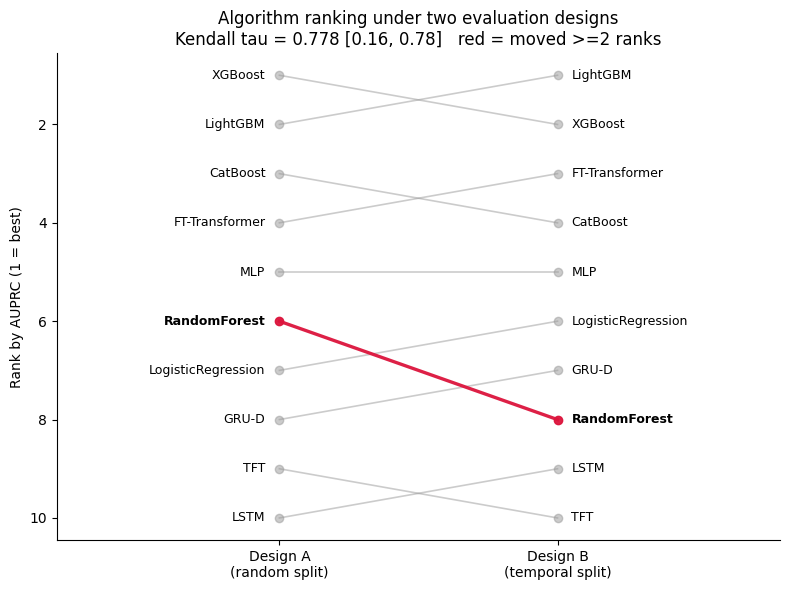

In [17]:
fig, ax = plt.subplots(figsize=(8,6))
for m in comp.index:
    a,b = comp.loc[m,'rank_A'], comp.loc[m,'rank_B']; mv = abs(a-b)>=2
    ax.plot([0,1],[a,b],'o-', color='crimson' if mv else '#999',
            lw=2.4 if mv else 1.2, alpha=.95 if mv else .5, zorder=3 if mv else 1)
    ax.text(-.05,a,m,ha='right',va='center',fontsize=9,fontweight='bold' if mv else 'normal')
    ax.text(1.05,b,m,ha='left', va='center',fontsize=9,fontweight='bold' if mv else 'normal')
ax.set_xlim(-.8,1.8); ax.invert_yaxis(); ax.set_xticks([0,1])
ax.set_xticklabels(['Design A\n(random split)','Design B\n(temporal split)'])
ax.set_ylabel('Rank by AUPRC (1 = best)')
ax.set_title(f'Algorithm ranking under two evaluation designs\n'
             f'Kendall tau = {tau:.3f} [{lo:.2f}, {hi:.2f}]   red = moved >=2 ranks')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig1_rank_comparison.png", dpi=220); plt.show()

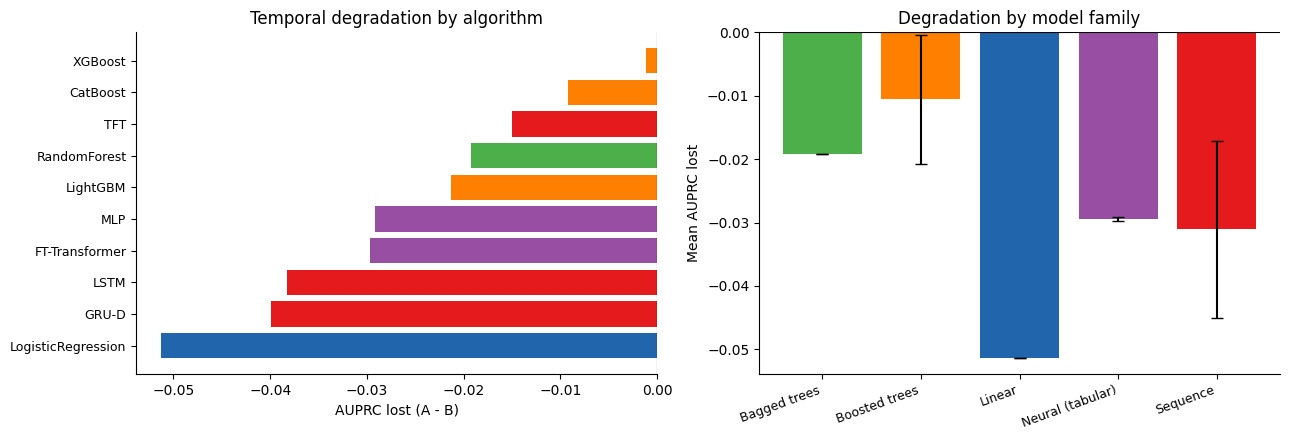

,mean,std,count
family,,,
Bagged trees,-0.0192,NaN,1
Boosted trees,-0.0105,0.0102,3
Linear,-0.0513,NaN,1
Neural (tabular),-0.0294,0.0004,2
Sequence,-0.0311,0.0139,3


In [18]:
fig, axes = plt.subplots(1,2, figsize=(13,4.5))
COL = {'Linear':'#2166ac','Bagged trees':'#4daf4a','Boosted trees':'#ff7f00',
       'Neural (tabular)':'#984ea3','Sequence':'#e41a1c'}
o = comp.sort_values('degradation')
axes[0].barh(range(len(o)), o.degradation, color=[COL.get(f,'grey') for f in o.family])
axes[0].set_yticks(range(len(o))); axes[0].set_yticklabels(o.index, fontsize=9)
axes[0].axvline(0,color='k',lw=.8); axes[0].set_xlabel('AUPRC lost (A - B)')
axes[0].set_title('Temporal degradation by algorithm')
axes[0].spines[['top','right']].set_visible(False)

fam = comp.groupby('family')['degradation'].agg(['mean','std','count'])
axes[1].bar(range(len(fam)), fam['mean'], yerr=fam['std'].fillna(0), capsize=4,
            color=[COL.get(f,'grey') for f in fam.index])
axes[1].set_xticks(range(len(fam)))
axes[1].set_xticklabels(fam.index, rotation=20, ha='right', fontsize=9)
axes[1].axhline(0,color='k',lw=.8); axes[1].set_ylabel('Mean AUPRC lost')
axes[1].set_title('Degradation by model family')
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig2_degradation.png", dpi=220); plt.show()
display(fam.round(4))

## 12. Calibration

H3 predicts calibration degrades faster than discrimination, because E5 prevalence
(13.6%) exceeds training prevalence (10.6%) while the rank ordering of risk is
comparatively conserved.

In [19]:
cal = res_all.pivot(index='model', columns='design',
                    values=['cal_slope','cal_intercept','brier'])
cal.columns = [f"{a}_{b}" for a,b in cal.columns]
display(cal.round(3))

A, B = ML[ML.design=='A'], ML[ML.design=='B']
d_auprc = 100*(A.auprc.mean()-B.auprc.mean())/A.auprc.mean()
d_slope = 100*(A.cal_slope.mean()-B.cal_slope.mean())/A.cal_slope.mean()
print(f"\nMean calibration slope      A {A.cal_slope.mean():.3f} -> B {B.cal_slope.mean():.3f}")
print(f"Mean calibration intercept  A {A.cal_intercept.mean():.3f} -> B {B.cal_intercept.mean():.3f}")
print(f"Mean Brier                  A {A.brier.mean():.4f} -> B {B.brier.mean():.4f}")
print(f"\nRelative AUPRC loss          {d_auprc:.1f}%")
print(f"Relative calibration change  {d_slope:.1f}%")
print("H3 supported" if abs(d_slope) > abs(d_auprc) else "H3 not supported")

,cal_slope_A,cal_slope_B,cal_intercept_A,cal_intercept_B,brier_A,brier_B
model,,,,,,
CatBoost,1.101,0.768,-1.517,-0.261,0.096,0.077
FT-Transformer,0.836,0.943,-1.627,-1.988,0.107,0.145
GRU-D,0.858,0.863,-1.773,-1.583,0.127,0.128
LSTM,0.849,1.004,-1.791,-1.729,0.130,0.134
LightGBM,0.322,0.829,-0.028,-0.525,0.072,0.078
LogisticRegression,0.751,0.838,-1.926,-2.197,0.127,0.164
MLP,1.067,0.980,0.013,0.085,0.066,0.077
RandomForest,1.270,1.510,-0.897,-1.309,0.084,0.113
SAPS-II (lite),1.059,1.121,0.114,0.440,0.090,0.105



Mean calibration slope      A 0.895 -> B 0.949
Mean calibration intercept  A -1.276 -> B -1.158
Mean Brier                  A 0.1026 -> B 0.1121

Relative AUPRC loss          -4.4%
Relative calibration change  -5.9%
H3 supported


## 13. Sensitivity analyses

**SA4 is the most important.** If ranking instability disappears when E5 is removed, the
honest conclusion is that a pandemic disrupts model ranking &mdash; not that ordinary
temporal drift does. That is a narrower claim and must be reported as such.

In [20]:
# SA1 - rank by AUROC instead of AUPRC (runs on existing results, no refit).
tA = ML[ML.design=='A'].set_index('model')['auroc'].rank(ascending=False)
tB = ML[ML.design=='B'].set_index('model')['auroc'].rank(ascending=False)
tau_auroc = kendalltau(tA, tB)[0]
print(f"SA1  Rank by AUROC:  tau = {tau_auroc:.3f}   (primary AUPRC: {tau:.3f})")
print("     Robust to metric choice." if abs(tau_auroc-tau) < .15
      else "     *** Metric choice changes the conclusion - report both. ***")

# SA4 - exclude E5. Re-run the notebook with these overrides in make_splits():
#   train = E1,E2   val = E3   test = E4
e = df[DESIGN].values
print("\nSA4 partition sizes (train E1+E2 / val E3 / test E4):")
for nm, mk in [('train', np.isin(e,['E1','E2'])), ('val', e=='E3'), ('test', e=='E4')]:
    n=int(mk.sum()); d_=int(df[TARGET].values[mk].sum())
    print(f"  {nm:6s} {n:>6,} stays | {d_:>4,} deaths | {100*d_/n:5.2f}%")

print("""
To run SA2/SA3/SA4, change make_splits() and re-run from Section 7 with a
different STORAGE filename so the studies do not collide:

  SA2  12-hour window   -> rebuild dataset with INTERVAL 12 HOUR in the SQL
  SA3  train E1-E4      -> isolates sample-size effects from temporal shift
  SA4  train E1+E2, val E3, test E4  -> isolates the COVID era
""")

SA1  Rank by AUROC:  tau = 0.778   (primary AUPRC: 0.778)
     Robust to metric choice.

SA4 partition sizes (train E1+E2 / val E3 / test E4):
  train  11,976 stays | 1,233 deaths | 10.30%
  val     7,068 stays |  779 deaths | 11.02%
  test    7,321 stays |  792 deaths | 10.82%

To run SA2/SA3/SA4, change make_splits() and re-run from Section 7 with a
different STORAGE filename so the studies do not collide:

  SA2  12-hour window   -> rebuild dataset with INTERVAL 12 HOUR in the SQL
  SA3  train E1-E4      -> isolates sample-size effects from temporal shift
  SA4  train E1+E2, val E3, test E4  -> isolates the COVID era



## 14. Export

In [21]:
comp.to_csv(f"{OUT_DIR}/ranking_comparison.csv")
cal.to_csv(f"{OUT_DIR}/table_calibration.csv")

summary = dict(
  research_question='Does ML algorithm ranking survive temporal validation?',
  kendall_tau=float(tau), kendall_p=float(pval), tau_ci_95=[float(lo),float(hi)],
  hypothesis_supported=bool(hi < 0.999),
  models_moved_2plus=int(moved), n_ml_models=int(len(comp)),
  best_design_A=comp.index[0], best_design_B=comp.sort_values('rank_B').index[0],
  mean_degradation_auprc=float(comp.degradation.mean()),
  mean_degradation_pct=float(comp.degradation_pct.mean()),
  tau_auroc_sensitivity=float(tau_auroc),
  n_trials=N_TRIALS, n_seeds=N_SEEDS,
  cohort_size=int(len(df)), n_features=len(FEATURES),
  train_prevalence=float(df[df.era.isin(['E1','E2','E3'])][TARGET].mean()),
  test_prevalence=float(df[df.era=='E5'][TARGET].mean()),
)
json.dump(summary, open(f"{OUT_DIR}/FINAL_SUMMARY.json","w"), indent=2)
print(json.dumps(summary, indent=2))
print("\nFiles:")
for f_ in sorted(os.listdir(OUT_DIR)): print("  ", f_)

{
  "research_question": "Does ML algorithm ranking survive temporal validation?",
  "kendall_tau": 0.7777777777777777,
  "kendall_p": 0.0009463183421516755,
  "tau_ci_95": [
    0.15555555555555553,
    0.7777777777777777
  ],
  "hypothesis_supported": true,
  "models_moved_2plus": 1,
  "n_ml_models": 10,
  "best_design_A": "XGBoost",
  "best_design_B": "LightGBM",
  "mean_degradation_auprc": -0.025420000000000005,
  "mean_degradation_pct": -4.51,
  "tau_auroc_sensitivity": 0.7777777777777777,
  "n_trials": 30,
  "n_seeds": 5,
  "cohort_size": 32315,
  "n_features": 260,
  "train_prevalence": 0.10565007351396766,
  "test_prevalence": 0.13563025210084034
}

Files:
   FINAL_SUMMARY.json
   all_model_results.csv
   all_predictions.npz
   all_results_with_scores.csv
   best_params.json
   fig1_rank_comparison.png
   fig2_degradation.png
   optuna_studies.db
   ranking_comparison.csv
   table_calibration.csv


In [22]:
import shutil
shutil.make_archive('/kaggle/working/results_backup', 'zip', OUT_DIR)
print("Download results_backup.zip from the Output tab before closing")

Download results_backup.zip from the Output tab before closing


---

## Reading the result

**tau well below 1, CI excludes 1** &rarr; random splitting can select a different algorithm
than temporal validation would. Report which models moved, in which direction, and
whether capacity predicts movement.

**tau near 1, CI includes 1** &rarr; conventional benchmarking selects the same model
despite its theoretical weakness. Publishable, currently unestablished, useful.

### Caveats for the write-up

- E5 prevalence (13.6%) exceeds training prevalence (10.6%). Higher prevalence
  mechanically raises AUPRC, so a model can look *better* under Design B for reasons
  unrelated to robustness. Read degradation alongside the prevalence column.
- Design B trains on 19,044 stays vs Design A's 22,620 &mdash; SA3 isolates that.
- SOFA and SAPS-II are **modified**, missing components dependent on the excluded
  `inputevents`/`outputevents`/`procedureevents` tables.
- Organ-support features excluded entirely (~43% E5 coverage vs ~100% in E1&ndash;E4).
- Cohort restricted to `year_offset = 0`: 50.9% of first stays retained in E1 rising
  to 95.0% in E5.